<a href="https://colab.research.google.com/github/LielUziahu/12th_GetTogether/blob/main/Histology_Morphometrics_and_Lipids.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Block 1: Environment Setup & Academic Aesthetics
This block loads your required data science and library dependencies while locking in a clean, publication-ready styling layout.

In [1]:
# =========================================================================
# BLOCK 1: ENVIRONMENT SETUP & SCIENTIFIC STYLING
# =========================================================================
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Configure publication-quality visual environment
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams['svg.fonttype'] = 'none'  # Keeps text editable if exported to vector Illustrator format
sns.set_theme(style="whitegrid")

# Establish cohesive, project-standard color maps for your morphotypes
variant_colors = {'HF': '#66c2a5', 'NF': '#fc8d62'}
morph_order = ['HF', 'NF']

print("✓ Block 1: Analysis libraries loaded and visual styles locked.")

✓ Block 1: Analysis libraries loaded and visual styles locked.


# Block 2: Data Import, Merging, and Tissue Engineering
This block reads both raw CSV sheets, extracts the HF versus NF morph labels directly from your file strings, and builds the missing gastrodermal target proxy (Vacuole_Percentage_Endoderm).

In [2]:
# =========================================================================
# BLOCK 2: DATA LOADING, EXCLUSIONS, AND TISSUE ENGINEERING
# =========================================================================

# 1. Read input CSV files
df_morph = pd.read_csv("Larvae_Morphometrics_Report.csv")
df_cons = pd.read_csv("Larvae_Consumption_Data.csv").dropna(subset=['File_Name'])

# 2. Extract Morph identities uniformly from file name paths
df_morph['Morph'] = df_morph['File_Name'].apply(lambda x: 'HF' if '_HF' in x or '_hf' in x.lower() else ('NF' if '_NF' in x or '_nf' in x.lower() else 'Unknown'))
df_cons['Morph'] = df_cons['File_Name'].apply(lambda x: 'HF' if '_HF' in x or '_hf' in x.lower() else ('NF' if '_NF' in x or '_nf' in x.lower() else 'Unknown'))

# 3. Perform Unit Conversion: um2 to mm2 for Larval Area
df_morph['Total_Area_mm2'] = df_morph['Total_Area_um2'] / 1000000

# 4. Calculate Gastrodermal Energy Packing Density
df_cons['Vacuole_Percentage_Endoderm'] = (df_cons['Total_Vacuole_Area'] / df_cons['Endoderm_Area']) * 100

# 5. Merge data components on File_Name to create an easily managed master workspace
master_df = pd.merge(
    df_morph[['File_Name', 'Morph', 'Ecto_Avg', 'Total_Area_mm2', 'Gastro_Cavity_Area_um2']],
    df_cons[['File_Name', 'Morph', 'Vacuole_Percentage_Total', 'Vacuole_Percentage_Endoderm', 'Consumption_Index']],
    on=['File_Name', 'Morph'],
    how='inner'
)

print(f"✓ Block 2 Complete. Master dataframe unified with Area in mm2. Samples remaining: {len(master_df)}")
print(master_df['Morph'].value_counts())

✓ Block 2 Complete. Master dataframe unified with Area in mm2. Samples remaining: 26
Morph
HF    14
NF    12
Name: count, dtype: int64


# Block 3: Localized Outlier Extraction
To ensure your gold-standard analytical parameters remain perfectly standardized, this standalone function calculates the $1.5 \times \text{IQR}$ barrier independently within each morphotype group before running any stats or plots.

In [3]:
# =========================================================================
# BLOCK 3: GROUP-WISE OUTLIER PRUNING FUNCTION
# =========================================================================

def prune_group_outliers(data, group_col, target_col):
    """
    Slices the dataframe by morph group, isolates fence posts using the
    strict 1.5xIQR standard, and purges anomalies independently.
    """
    clean_dfs = []
    for group_name in data[group_col].unique():
        sub_group = data[data[group_col] == group_name]

        q1 = sub_group[target_col].quantile(0.25)
        q3 = sub_group[target_col].quantile(0.75)
        iqr = q3 - q1

        lower_post = q1 - 1.5 * iqr
        upper_post = q3 + 1.5 * iqr

        # Keep only replicates trapped inside the valid fence rows
        sub_group_clean = sub_group[(sub_group[target_col] >= lower_post) & (sub_group[target_col] <= upper_post)]
        clean_dfs.append(sub_group_clean)

    return pd.concat(clean_dfs)

print("✓ Block 3 Complete: Strict 1.5xIQR group-wise filtering algorithm initialized.")

✓ Block 3 Complete: Strict 1.5xIQR group-wise filtering algorithm initialized.


# Block 4: Automated Testing Engine
This core block performs normality checks (Shapiro-Wilk) group-by-group. If both cohorts are normal, it runs a Welch's t-test. If any group violates normality, it automatically switches to a non-parametric Mann-Whitney U test.


In [4]:
# =========================================================================
# BLOCK 4: AUTOMATED PHYSIOLOGICAL STATISTICAL ASSAY
# =========================================================================

# Updated to use the new mm2 column name
metrics_to_test = ['Ecto_Avg', 'Total_Area_mm2', 'Vacuole_Percentage_Total', 'Vacuole_Percentage_Endoderm', 'Consumption_Index']
stat_results_cache = {}

print("=========================================================================")
print("📊 COMPREHENSIVE PATHOLOGICAL TELEMETRY")
print("=========================================================================\n")

for metric in metrics_to_test:
    # Extract data cleaned
    df_metric_clean = prune_group_outliers(master_df, 'Morph', metric)

    hf_sample = df_metric_clean[df_metric_clean['Morph'] == 'HF'][metric]
    nf_sample = df_metric_clean[df_metric_clean['Morph'] == 'NF'][metric]

    # Check Normality assumptions
    _, hf_shapiro_p = stats.shapiro(hf_sample) if len(hf_sample) >= 3 else (0, 0)
    _, nf_shapiro_p = stats.shapiro(nf_sample) if len(nf_sample) >= 3 else (0, 0)

    is_normal = (hf_shapiro_p > 0.05) and (nf_shapiro_p > 0.05)

    # Execute the optimal downstream statistical path dynamically
    if is_normal:
        t_stat, p_value = stats.ttest_ind(hf_sample, nf_sample, equal_var=False)
        test_used = "Welch's Parametric T-Test"
    else:
        t_stat, p_value = stats.mannwhitneyu(hf_sample, nf_sample, alternative='two-sided')
        test_used = "Non-Parametric Mann-Whitney U"

    # Cache the p-value result to overlay directly onto the graphs
    stat_results_cache[metric] = p_value

    print(f"Variable: {metric}")
    print(f"  • Mean (HF): {hf_sample.mean():.4f}, Mean (NF): {nf_sample.mean():.4f}, p = {p_value:.4f}")
    print("-" * 73)

📊 COMPREHENSIVE PATHOLOGICAL TELEMETRY

Variable: Ecto_Avg
  • Mean (HF): 43.7071, Mean (NF): 51.3489, p = 0.0205
-------------------------------------------------------------------------
Variable: Total_Area_mm2
  • Mean (HF): 0.2655, Mean (NF): 0.3052, p = 0.1506
-------------------------------------------------------------------------
Variable: Vacuole_Percentage_Total
  • Mean (HF): 28.9306, Mean (NF): 33.1234, p = 0.0738
-------------------------------------------------------------------------
Variable: Vacuole_Percentage_Endoderm
  • Mean (HF): 43.7329, Mean (NF): 50.4204, p = 0.0260
-------------------------------------------------------------------------
Variable: Consumption_Index
  • Mean (HF): 0.1181, Mean (NF): 0.1943, p = 0.0352
-------------------------------------------------------------------------


# Block 5: Global Plot Styling
This defines the aesthetic the plots to ensure consistency.

In [5]:
# --- GLOBAL PLOT STYLING ---
plt.rcParams.update({
    "font.family": "Serif",
    "font.size": 14,          # Global text size
    "axes.titlesize": 16,     # Plot titles
    "axes.titleweight": "bold", # Global title fontweight
    "axes.titlepad": 25,      # Global title padding
    "axes.labelsize": 14,     # Axis labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2,
    "axes.grid": False        # Disable grid lines globally
})

# --- GLOBAL ARTIFACTS ---
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}
global_fig_size = (6, 6)
global_jitter = 0.1
global_marker_size = 5
global_alpha = 0.6 # Used for boxplot and stripplot fill transparency
global_box_width = 0.4
global_asterisk_size = 18
global_asterisk_weight = 'bold'
global_jitter_edgecolor = 'black' # New global setting for jitter outline color
global_jitter_linewidth = 1     # New global setting for jitter outline width
global_y_nbins = 3

print("Styles initialized. Grid lines disabled.")

Styles initialized. Grid lines disabled.


# Block 6: Individual 600 DPI Publication Graph Generator
This final block iterates through your metrics, extracts clean outliers, overlays raw individual data points to guarantee tracking transparency, applies your color map palette, prints the precise statistical p-value outcome on the frame, and saves individual, high-resolution vector files at 600 DPI.

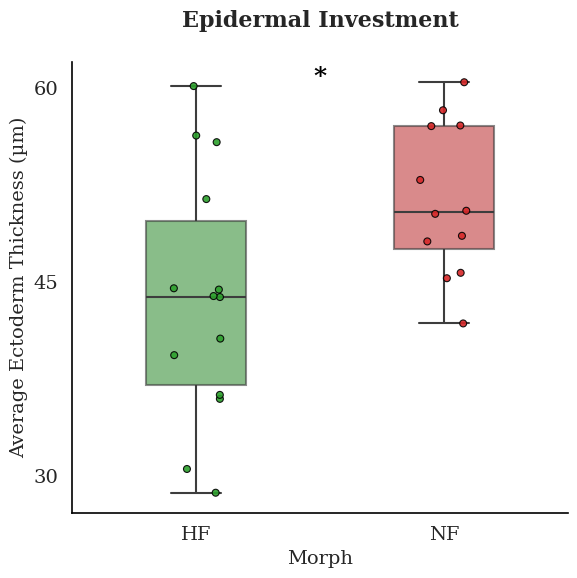

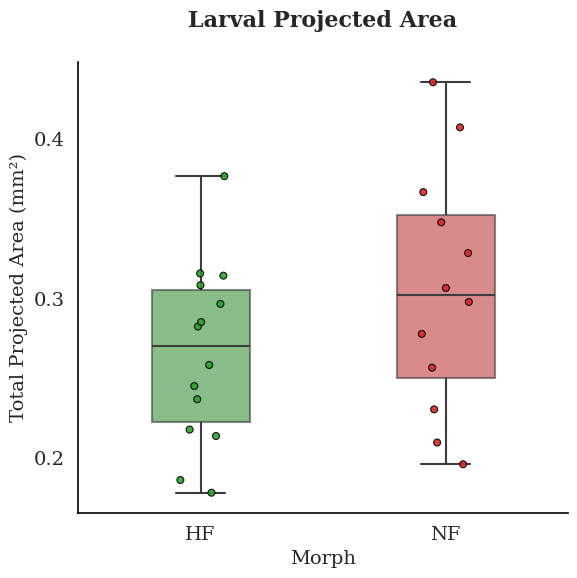

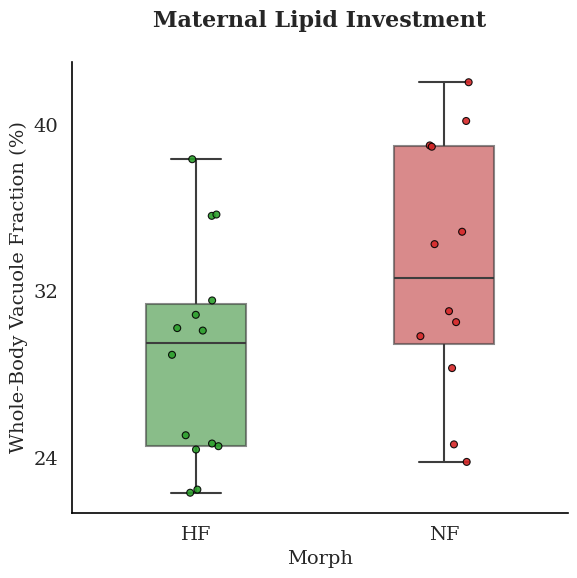

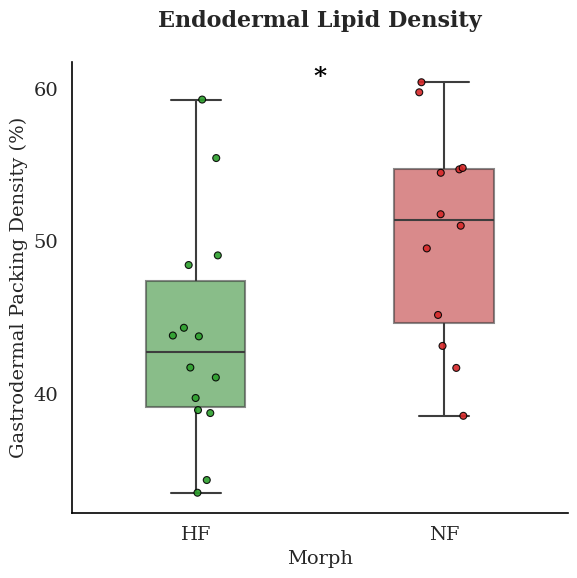

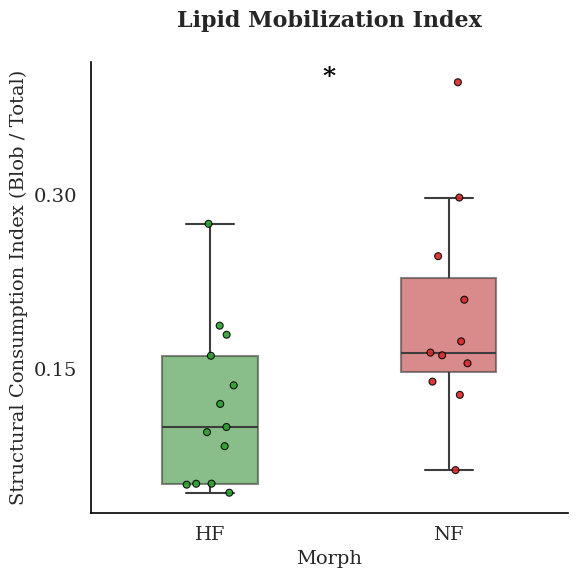

In [6]:
# =========================================================================
# BLOCK 6: HIGH-RESOLUTION INDIVIDUAL PLOT LOOP (600 DPI)
# =========================================================================

y_label_dictionary = {
    'Ecto_Avg': 'Average Ectoderm Thickness (µm)',
    'Total_Area_mm2': 'Total Projected Area (mm²)',
    'Vacuole_Percentage_Total': 'Whole-Body Vacuole Fraction (%)',
    'Vacuole_Percentage_Endoderm': 'Gastrodermal Packing Density (%)',
    'Consumption_Index': 'Structural Consumption Index (Blob / Total)'
}

title_dictionary = {
    'Ecto_Avg': 'Epidermal Investment',
    'Total_Area_mm2': 'Larval Projected Area',
    'Vacuole_Percentage_Total': 'Maternal Lipid Investment',
    'Vacuole_Percentage_Endoderm': 'Endodermal Lipid Density',
    'Consumption_Index': 'Lipid Mobilization Index'
}

for metric in metrics_to_test:
    df_plot_clean = prune_group_outliers(master_df, 'Morph', metric)
    fig, ax = plt.subplots(figsize=global_fig_size)

    sns.boxplot(ax=ax, data=df_plot_clean, x='Morph', y=metric, hue='Morph', order=morph_order, palette=variant_colors, width=global_box_width, fliersize=0, linewidth=1.5, boxprops=dict(alpha=global_alpha), legend=False)
    sns.stripplot(ax=ax, data=df_plot_clean, x='Morph', y=metric, hue='Morph', order=morph_order, palette=variant_colors, size=global_marker_size, alpha=0.9, jitter=global_jitter, edgecolor=global_jitter_edgecolor, linewidth=0.8, legend=False)

    ax.set_title(title_dictionary[metric], pad=plt.rcParams['axes.titlepad'])
    ax.set_ylabel(y_label_dictionary[metric])
    ax.set_xlabel('Morph')
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=global_y_nbins))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    current_p = stat_results_cache[metric]
    stars = "***" if current_p < 0.001 else ("**" if current_p < 0.01 else ("*" if current_p < 0.05 else ""))
    if stars:
        ymin, ymax = ax.get_ylim()
        ax.text(0.5, ymax - (ymax-ymin)*0.05, stars, horizontalalignment='center', fontsize=global_asterisk_size, color='black', weight=global_asterisk_weight)

    plt.tight_layout()
    plt.show()

### Block 7: Multi-Panel Publication Summary Figure
This block aggregates all five physiological metrics into a single high-resolution panel for comparative analysis.

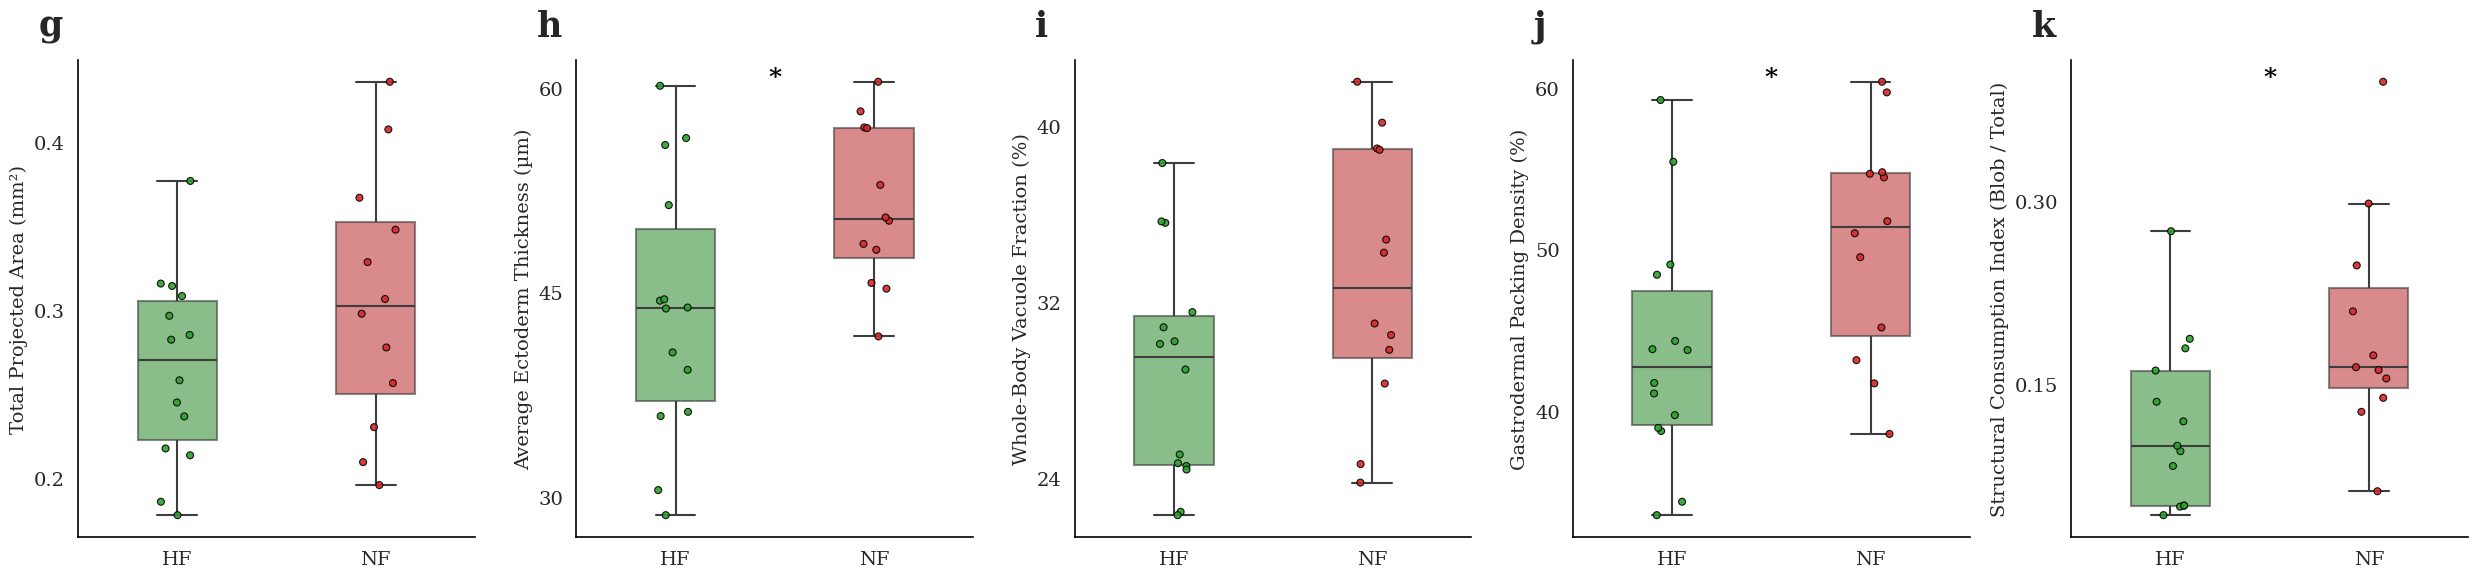

In [7]:
import string

# =========================================================================
# BLOCK 7: COMBINED 5-PANEL SUMMARY FIGURE (600 DPI)
# =========================================================================

combined_order = [
    'Total_Area_mm2',
    'Ecto_Avg',
    'Vacuole_Percentage_Total',
    'Vacuole_Percentage_Endoderm',
    'Consumption_Index'
]

fig, axes = plt.subplots(1, 5, figsize=(25, 6))

for i, metric in enumerate(combined_order):
    ax = axes[i]
    df_plot_clean = prune_group_outliers(master_df, 'Morph', metric)

    sns.boxplot(ax=ax, data=df_plot_clean, x='Morph', y=metric, hue='Morph', order=morph_order, palette=variant_colors, width=global_box_width, fliersize=0, linewidth=1.5, boxprops=dict(alpha=global_alpha), legend=False)
    sns.stripplot(ax=ax, data=df_plot_clean, x='Morph', y=metric, hue='Morph', order=morph_order, palette=variant_colors, size=global_marker_size, alpha=0.9, jitter=global_jitter, edgecolor=global_jitter_edgecolor, linewidth=0.8, legend=False)

    #ax.set_title(title_dictionary[metric], pad=20)
    ax.set_ylabel(y_label_dictionary[metric])
    ax.set_xlabel('')
    ax.grid(False) # Explicitly ensure grid is off for this panel
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=global_y_nbins))

    # Add 'g', 'h', 'i', 'j', 'k' labels to the top left of each subplot
    ax.text(-0.1, 1.05, string.ascii_lowercase[i+6], transform=ax.transAxes, size=25, weight='bold')

    current_p = stat_results_cache[metric]
    stars = "***" if current_p < 0.001 else ("**" if current_p < 0.01 else ("*" if current_p < 0.05 else ""))
    if stars:
        ymin, ymax = ax.get_ylim()
        ax.text(0.5, ymax - (ymax-ymin)*0.05, stars, horizontalalignment='center', fontsize=global_asterisk_size, color='black', weight=global_asterisk_weight)

plt.tight_layout()
plt.show()
fig.savefig("Histology_Morphometrics_and_Lipids.png", dpi=600, bbox_inches='tight')
fig.savefig("Histology_Morphometrics_and_Lipids.tiff", dpi=600, bbox_inches='tight')

### Block 8: Detailed Statistical Report
This block generates a formatted summary of all physiological metrics, providing the raw values and test statistics used in the publication figures.

In [8]:
import pandas as pd

# --- DETAILED STATISTICAL REPORT GENERATOR ---
stats_report = []

for metric in metrics_to_test:
    # Use the same outlier pruning logic as the plots
    df_clean = prune_group_outliers(master_df, 'Morph', metric)

    hf_data = df_clean[df_clean['Morph'] == 'HF'][metric]
    nf_data = df_clean[df_clean['Morph'] == 'NF'][metric]

    # Descriptive Stats
    report_entry = {
        'Metric': title_dictionary[metric],
        'HF_Mean': hf_data.mean(),
        'HF_SEM': hf_data.sem(),
        'HF_N': len(hf_data),
        'NF_Mean': nf_data.mean(),
        'NF_SEM': nf_data.sem(),
        'NF_N': len(nf_data),
        'P_Value': stat_results_cache[metric],
        'Significance': "***" if stat_results_cache[metric] < 0.001 else ("**" if stat_results_cache[metric] < 0.01 else ("*" if stat_results_cache[metric] < 0.05 else "ns"))
    }
    stats_report.append(report_entry)

# Create a clean DataFrame for display
df_stats_summary = pd.DataFrame(stats_report)

print("=========================================================================")
print("📜 FULL PUBLICATION STATISTICAL SUMMARY")
print("=========================================================================")
display(df_stats_summary.round(4))

# Optional: Export to CSV for supplement
df_stats_summary.to_csv("full_statistical_output.csv", index=False)
print("\n✓ Statistical summary exported to 'full_statistical_output.csv'")

📜 FULL PUBLICATION STATISTICAL SUMMARY


,Metric,HF_Mean,HF_SEM,HF_N,NF_Mean,NF_SEM,NF_N,P_Value,Significance
0,Epidermal Investment,43.7071,2.5467,14,51.3489,1.6943,12,0.0205,*
1,Larval Projected Area,0.2655,0.0150,14,0.3052,0.0219,12,0.1506,ns
2,Maternal Lipid Investment,28.9306,1.3855,14,33.1234,1.7505,12,0.0738,ns
3,Endodermal Lipid Density,43.7329,1.9569,14,50.4204,2.0247,12,0.0260,*
4,Lipid Mobilization Index,0.1181,0.0190,13,0.1943,0.0276,11,0.0352,*



✓ Statistical summary exported to 'full_statistical_output.csv'


### Block 9: Software Versions & Reproducibility
This block logs the specific versions of the software environment used to generate these results, ensuring consistent behavior for future re-analysis.

In [9]:
import sys
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import scipy

# --- SOFTWARE VERSION REPORT ---
print("=========================================================================")
print("🛠️ ANALYSIS REPRODUCIBILITY LOG")
print("=========================================================================")
print(f"Python Version:   {sys.version.split(' ')[0]}")
print(f"Pandas Version:   {pd.__version__}")
print(f"NumPy Version:    {np.__version__}")
print(f"SciPy Version:    {scipy.__version__}")
print(f"Matplotlib:       {matplotlib.__version__}")
print(f"Seaborn Version:  {sns.__version__}")
print("=========================================================================")

🛠️ ANALYSIS REPRODUCIBILITY LOG
Python Version:   3.13.15
Pandas Version:   2.2.3
NumPy Version:    2.1.3
SciPy Version:    1.16.3
Matplotlib:       3.10.0
Seaborn Version:  0.13.2


### Block 9: Outlier Report
This block generates a detailed report of all data points identified and removed as outliers by the `prune_group_outliers` function for each metric, grouped by morphotype.

In [10]:
outlier_report_data = []

for metric in metrics_to_test:
    # Original data for the metric
    original_df = master_df[['Morph', metric]].copy()

    # Cleaned data after outlier pruning
    cleaned_df = prune_group_outliers(master_df, 'Morph', metric)

    # Iterate through each morphotype (HF, NF) to find outliers
    for morph_type in ['HF', 'NF']:
        original_morph_data = original_df[original_df['Morph'] == morph_type]
        cleaned_morph_data = cleaned_df[cleaned_df['Morph'] == morph_type]

        # Find outliers by comparing original and cleaned dataframes
        # Convert to sets for efficient comparison, then find the difference
        original_values = set(original_morph_data[metric].values)
        cleaned_values = set(cleaned_morph_data[metric].values)

        outlier_values = list(original_values - cleaned_values)

        for outlier_val in outlier_values:
            outlier_report_data.append({
                'Metric': title_dictionary[metric],
                'treatment': 'Outlier Extraction',
                'Morph': morph_type,
                'value': outlier_val,
                'reason': 'Removed as 1.5xIQR outlier'
            })

# Create DataFrame for display
df_outlier_report = pd.DataFrame(outlier_report_data)

print("=========================================================================")
print("📈 OUTLIER EXTRACTION REPORT")
print("=========================================================================")
display(df_outlier_report)

# Optional: Export to CSV
df_outlier_report.to_csv("outlier_report.csv", index=False)

📈 OUTLIER EXTRACTION REPORT


,Metric,treatment,Morph,value,reason
0,Lipid Mobilization Index,Outlier Extraction,HF,0.3546,Removed as 1.5xIQR outlier
1,Lipid Mobilization Index,Outlier Extraction,NF,0.4319,Removed as 1.5xIQR outlier
